In [1]:
import scipy.io
mat = scipy.io.loadmat('mds_train.mat')

time_d = mat["time_matrix"]
print(mat)
print(f"{mat["coords"]=}")
#print(mat["time_matrix"])

{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Thu Dec  1 15:26:47 2016', '__version__': '1.0', '__globals__': [], 'coords': array([[ 4.8992653, 52.3779656],
       [ 4.4679424, 51.925473 ],
       [ 5.6975666, 50.8506634],
       [ 3.5869867, 51.4464235],
       [ 6.5618716, 53.2110297]]), 'distance': array([[0.        , 0.62513118, 1.72335051, 1.60929979, 1.85963854],
       [0.62513118, 0.        , 1.6331538 , 1.00278182, 2.45707052],
       [1.72335051, 1.6331538 , 0.        , 2.19305212, 2.51363327],
       [1.60929979, 1.00278182, 2.19305212, 0.        , 3.45886907],
       [1.85963854, 2.45707052, 2.51363327, 3.45886907, 0.        ]]), 'station_index': array([[array(['Amsterdam'], dtype='<U9'),
        array(['Rotterdam'], dtype='<U9'),
        array(['Maastricht'], dtype='<U10'),
        array(['Vlissingen'], dtype='<U10'),
        array(['Groningen'], dtype='<U9')]], dtype=object), 'time_matrix': array([[  0,  71, 146, 177, 127],
       [ 71,   0, 136, 104

In [5]:
import numpy as np
#print data
#Create the D matrix
D = np.array(time_d)
print(f"{D=}")

#Number of points
n = D.shape[0]

#Create the A matrix
A = -0.5 * D**2

#Create the centering Matrix
H = np.eye(n) - 1/n * np.ones((n,n))

#Create the centered inner product
B = np.matmul(np.matmul(H,A), H)

(eig_val, eig_vec) = np.linalg.eig(B)

print(f"{eig_val=}")


# Indices of the two largest eigenvalues
idx = np.argsort(eig_val)[-2:]

# Keep them in descending order (largest first)
idx = idx[::-1]

diag = np.diag(np.sqrt(eig_val[idx]))

X = np.matmul(eig_vec[:,idx],diag)

print(f"{X=}")

D=array([[  0,  71, 146, 177, 127],
       [ 71,   0, 136, 104, 159],
       [146, 136,   0, 208, 258],
       [177, 104, 208,   0, 279],
       [127, 159, 258, 279,   0]], dtype=uint16)
eig_val=array([-8.04792979e+03, -1.20631109e-12,  4.58698238e+03,  1.67445773e+04,
        2.37173701e+04])
X=array([[ -8.249068  , -77.11057946],
       [ 42.97011692, -57.14827419],
       [-99.22138206,  13.4624865 ],
       [102.52769824,  55.13079002],
       [-38.0273651 ,  65.66557712]])


In [6]:
import numpy as np
from scipy.linalg import orthogonal_procrustes

def procrustes(X, Y):
    # Center
    muX = X.mean(axis=0)
    muY = Y.mean(axis=0)

    X0 = X - muX
    Y0 = Y - muY

    # Optimal rotation
    R, _ = orthogonal_procrustes(Y0, X0)

    # Optimal scale
    s = np.trace((Y0 @ R).T @ X0) / np.trace(Y0.T @ Y0)

    # Transform
    Z = s * Y0 @ R + muX

    # Residual
    d = np.sum((X - Z)**2)

    return d, Z

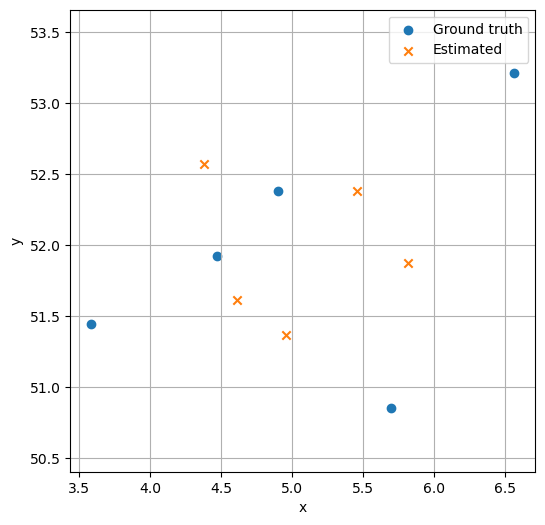

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(mat["coords"][:, 0], mat["coords"][:, 1],
            c='tab:blue', label='Ground truth')

_, Z = procrustes(mat["coords"], X)
plt.scatter(Z[:, 0], Z[:, 1],
            c='tab:orange', marker='x', label='Estimated')

plt.axis('equal')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)

plt.show()